# All Four Bell States

In this notebook, we generate and compare all four Bell states:

- |Φ⁺⟩ = (|00⟩ + |11⟩) / √2
- |Φ⁻⟩ = (|00⟩ − |11⟩) / √2
- |Ψ⁺⟩ = (|01⟩ + |10⟩) / √2
- |Ψ⁻⟩ = (|01⟩ − |10⟩) / √2

We will:
1. Construct each Bell state
2. Draw the circuits
3. Simulate measurements in the computational basis
4. Compare the outcomes
5. Verify the exact statevectors

In [3]:
!pip install qiskit qiskit-aer pylatexenc --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.2 MB/s eta 0:00:00


In [4]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

## Step 1: Define a function to generate Bell states

We first create the Bell state |Φ⁺⟩ using:

- Hadamard on qubit 0
- CNOT from qubit 0 to qubit 1

Then we use simple single-qubit gates to transform |Φ⁺⟩ into the other Bell states.

In [5]:
def bell_state_circuit(label="phi_plus", measure=True):
    """
    Create a 2-qubit circuit for one of the 4 Bell states.

    Allowed labels:
        - "phi_plus"   -> (|00> + |11>) / sqrt(2)
        - "phi_minus"  -> (|00> - |11>) / sqrt(2)
        - "psi_plus"   -> (|01> + |10>) / sqrt(2)
        - "psi_minus"  -> (|01> - |10>) / sqrt(2)

    Parameters
    ----------
    label : str
        Which Bell state to generate.
    measure : bool
        If True, add measurement at the end.

    Returns
    -------
    qc : QuantumCircuit
        The generated quantum circuit.
    """

    # 2 qubits, and 2 classical bits only if we want measurement
    if measure:
        qc = QuantumCircuit(2, 2)
    else:
        qc = QuantumCircuit(2)

    # Start from |00>
    # Step 1: Put qubit 0 into superposition
    qc.h(0)

    # Step 2: Entangle qubit 0 and qubit 1
    # This creates |phi+> = (|00> + |11>) / sqrt(2)
    qc.cx(0, 1)

    # Step 3: Convert |phi+> into the requested Bell state
    if label == "phi_plus":
        pass

    elif label == "phi_minus":
        # Add a phase flip
        qc.z(0)

    elif label == "psi_plus":
        # Flip second qubit to swap |00>,|11> -> |01>,|10>
        qc.x(1)

    elif label == "psi_minus":
        # First create psi_plus, then add phase flip
        qc.x(1)
        qc.z(0)

    else:
        raise ValueError(
            "Invalid label. Choose from: "
            "'phi_plus', 'phi_minus', 'psi_plus', 'psi_minus'"
        )

    # Optional measurement
    if measure:
        qc.measure([0, 1], [0, 1])

    return qc

## Step 2: Draw the circuits for all Bell states

This helps us visually see how each Bell state is generated.


Circuit for phi_plus:


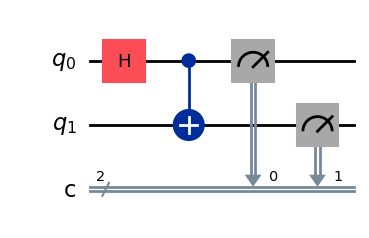


Circuit for phi_minus:


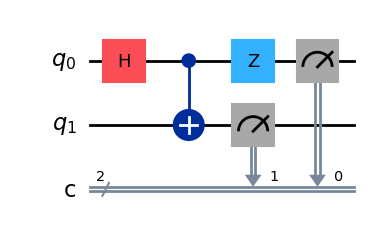


Circuit for psi_plus:


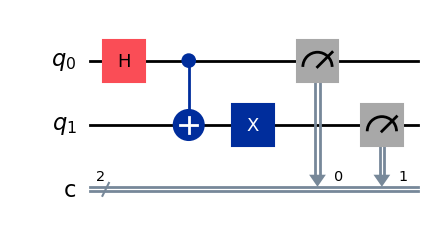


Circuit for psi_minus:


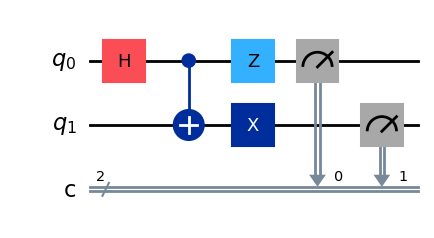

In [6]:
labels = ["phi_plus", "phi_minus", "psi_plus", "psi_minus"]

for label in labels:
    qc = bell_state_circuit(label=label, measure=True)
    print(f"\nCircuit for {label}:")
    display(qc.draw("mpl"))

## Step 3: Simulate measurements in the computational (Z) basis

We now measure each Bell state in the standard computational basis.

Expected behavior:

- |Φ⁺⟩ and |Φ⁻⟩ should produce only:
  - 00
  - 11

- |Ψ⁺⟩ and |Ψ⁻⟩ should produce only:
  - 01
  - 10

Notice that in the Z basis, the plus and minus states in each pair look the same in measurement probabilities.  
This is because the relative phase does not appear directly in Z-basis probabilities.


Measurement counts for phi_plus:
{'00': 519, '11': 505}


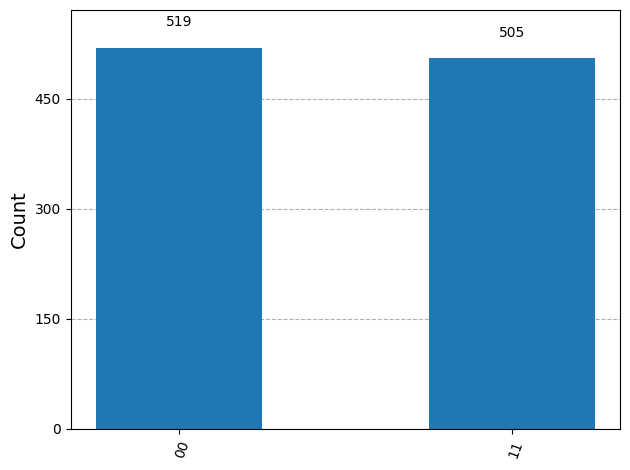


Measurement counts for phi_minus:
{'11': 515, '00': 509}


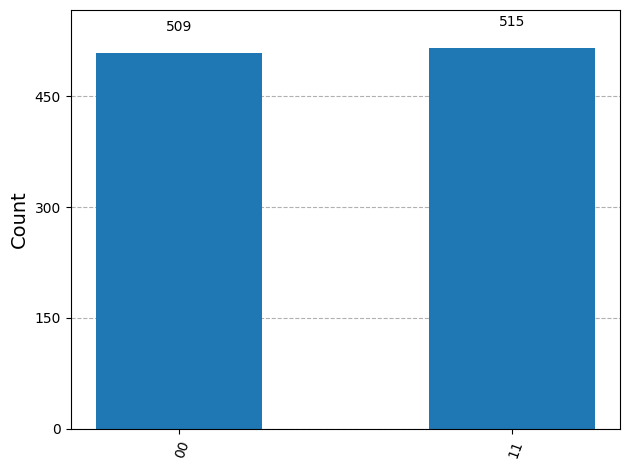


Measurement counts for psi_plus:
{'01': 534, '10': 490}


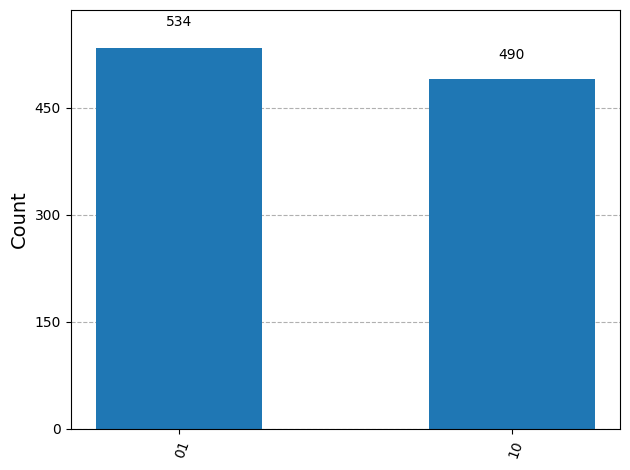


Measurement counts for psi_minus:
{'01': 507, '10': 517}


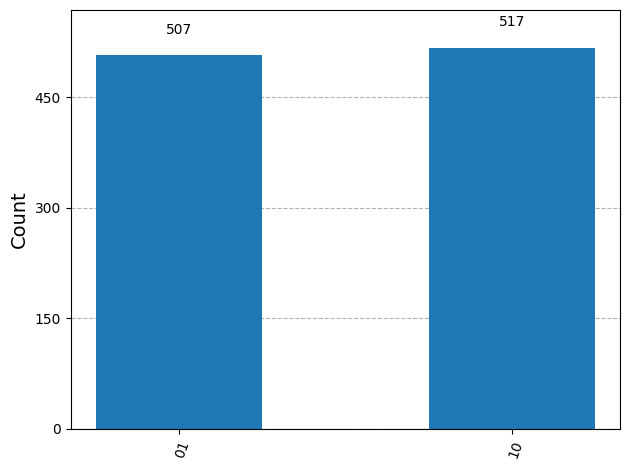

In [7]:
simulator = AerSimulator()
shots = 1024

all_counts = {}

for label in labels:
    qc = bell_state_circuit(label=label, measure=True)
    result = simulator.run(qc, shots=shots).result()
    counts = result.get_counts()
    all_counts[label] = counts

    print(f"\nMeasurement counts for {label}:")
    print(counts)

    fig = plot_histogram(counts)
    display(fig)

In [8]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

def bell_state_x_basis_circuit(label="phi_plus"):
    """
    Create a Bell state and measure both qubits in the X basis.

    X-basis measurement is implemented by applying H before Z-basis measurement.
    """

    qc = QuantumCircuit(2, 2)

    # --- Create the requested Bell state ---
    qc.h(0)
    qc.cx(0, 1)

    if label == "phi_plus":
        pass
    elif label == "phi_minus":
        qc.z(0)
    elif label == "psi_plus":
        qc.x(1)
    elif label == "psi_minus":
        qc.x(1)
        qc.z(0)
    else:
        raise ValueError("Choose from 'phi_plus', 'phi_minus', 'psi_plus', 'psi_minus'")

    # --- Convert X-basis measurement into standard measurement ---
    # Measuring in X basis = apply H, then measure in computational basis
    qc.h(0)
    qc.h(1)

    qc.measure([0, 1], [0, 1])

    return qc


X-basis measurement circuit for phi_plus:


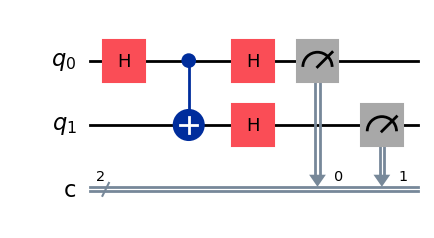


X-basis measurement circuit for phi_minus:


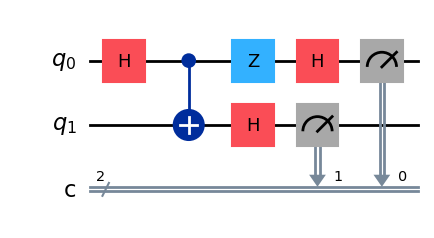


X-basis measurement circuit for psi_plus:


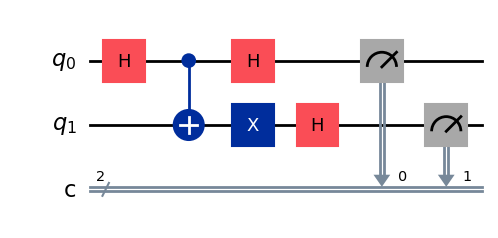


X-basis measurement circuit for psi_minus:


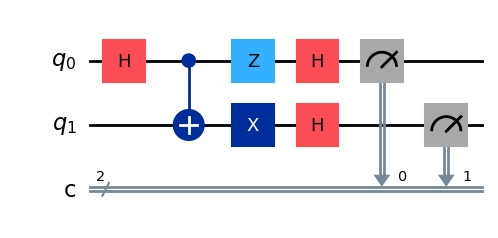

In [9]:
labels = ["phi_plus", "phi_minus", "psi_plus", "psi_minus"]

for label in labels:
    qc = bell_state_x_basis_circuit(label)
    print(f"\nX-basis measurement circuit for {label}:")
    display(qc.draw("mpl"))

In [10]:
simulator = AerSimulator()

for label in labels:
    qc = bell_state_x_basis_circuit(label)
    result = simulator.run(qc, shots=1024).result()
    counts = result.get_counts()

    print(f"\nX-basis counts for {label}:")
    print(counts)
    plt.show()


X-basis counts for phi_plus:
{'11': 494, '00': 530}

X-basis counts for phi_minus:
{'01': 524, '10': 500}

X-basis counts for psi_plus:
{'11': 514, '00': 510}

X-basis counts for psi_minus:
{'01': 503, '10': 521}


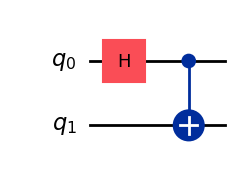

Statevector of Phi+:
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


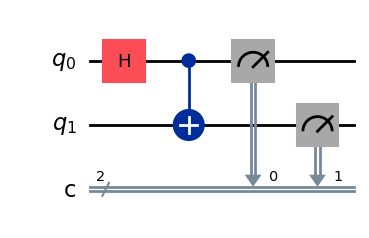

Measurement counts for Phi+:
{'11': 521, '00': 503}
Measurement counts for Phi+:
{'11': 521, '00': 503}


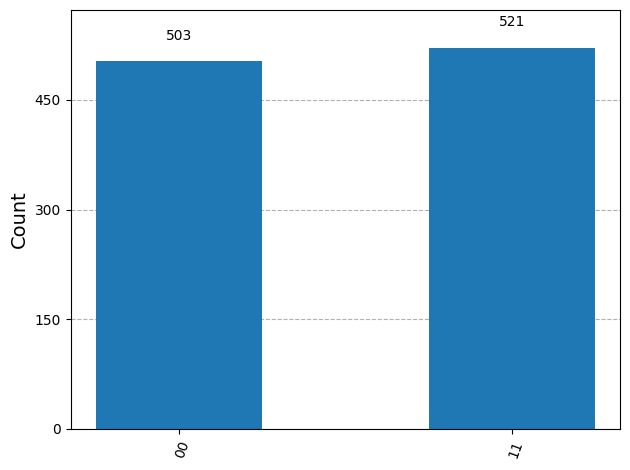

In [11]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
# -----------------------------
# 1. Create Phi+ without measurement
# -----------------------------
qc_phi_plus = QuantumCircuit(2)

# Put qubit 0 into superposition
qc_phi_plus.h(0)

# Entangle qubit 0 and qubit 1
qc_phi_plus.cx(0, 1)

# Draw the circuit
display(qc_phi_plus.draw("mpl"))

# Check the exact statevector
state_phi_plus = Statevector.from_instruction(qc_phi_plus)
print("Statevector of Phi+:")
print(state_phi_plus)

# -----------------------------
# 2. Create Phi+ with measurement
# -----------------------------
qc_phi_plus_meas = QuantumCircuit(2, 2)

qc_phi_plus_meas.h(0)
qc_phi_plus_meas.cx(0, 1)

qc_phi_plus_meas.measure([0, 1], [0, 1])

# Draw measured circuit
display(qc_phi_plus_meas.draw("mpl"))

# -----------------------------
# 3. Simulate
# -----------------------------
simulator = AerSimulator()
job = simulator.run(qc_phi_plus_meas, shots=1024)
result = job.result()
counts = result.get_counts()

print("Measurement counts for Phi+:")
print(counts)

# Plot results
counts = result.get_counts()

print("Measurement counts for Phi+:")
print(counts)

# Correct display
fig = plot_histogram(counts)
display(fig)

A0B0 with bases (Z, W)
Counts: {'01': 282, '11': 1741, '10': 284, '00': 1789}
Correlation E = 0.7236328125
--------------------------------------------------
A0B1 with bases (Z, V)
Counts: {'11': 1713, '10': 316, '00': 1764, '01': 303}
Correlation E = 0.69775390625
--------------------------------------------------
A1B0 with bases (X, W)
Counts: {'01': 312, '11': 1701, '10': 303, '00': 1780}
Correlation E = 0.69970703125
--------------------------------------------------
A1B1 with bases (X, V)
Counts: {'11': 300, '01': 1726, '00': 288, '10': 1782}
Correlation E = -0.712890625
--------------------------------------------------

Final CHSH result
S = 2.833984375
Classical bound = 2
Quantum maximum =  2.8284271247461903

Histogram for A0B0


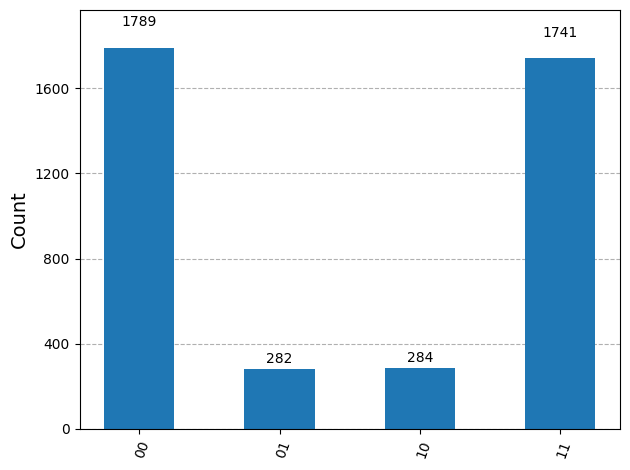


Histogram for A0B1


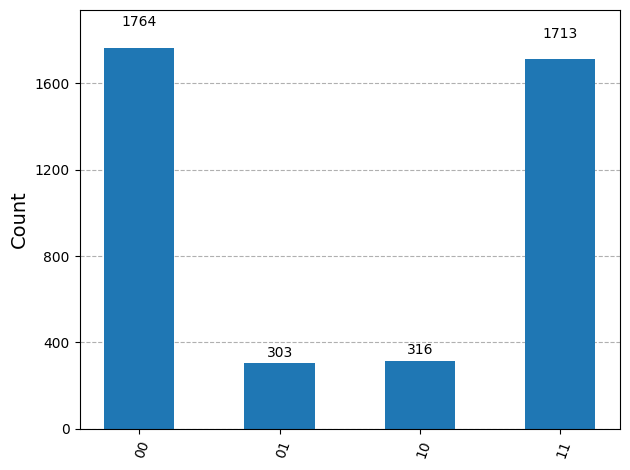


Histogram for A1B0


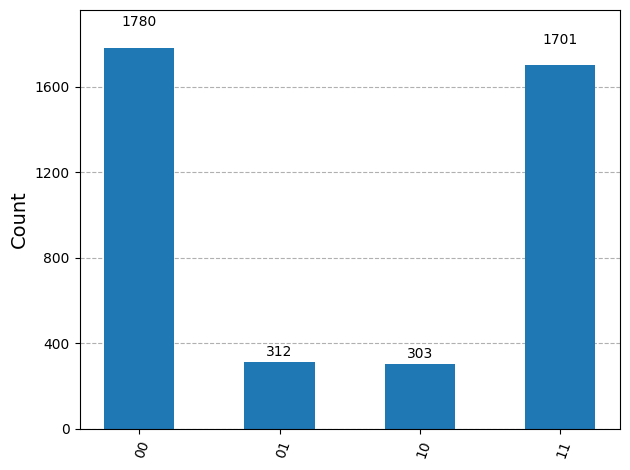


Histogram for A1B1


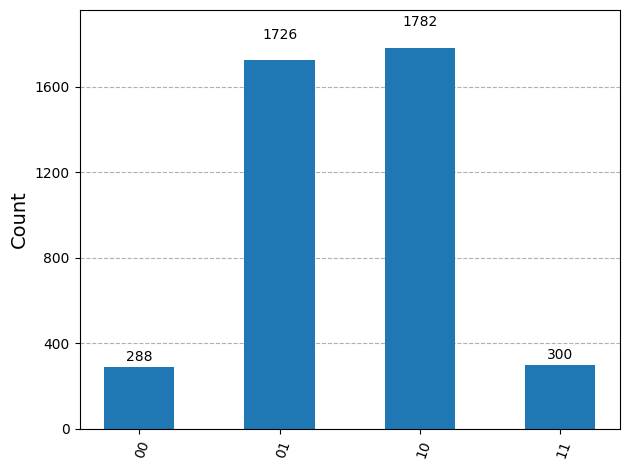

In [12]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.pyplot as plt

def apply_measurement_basis(qc, qubit, basis):
    if basis == 'Z':
        pass
    elif basis == 'X':
        qc.h(qubit)
    elif basis == 'W':
        qc.ry(-np.pi/4, qubit)   # (Z + X)/sqrt(2)
    elif basis == 'V':
        qc.ry(np.pi/4, qubit)    # (Z - X)/sqrt(2)
    else:
        raise ValueError("Basis must be one of: 'Z', 'X', 'W', 'V'")

def chsh_circuit(alice_basis, bob_basis):
    qc = QuantumCircuit(2, 2)

    # Prepare Bell state |Phi+>
    qc.h(0)
    qc.cx(0, 1)

    # Apply basis rotations
    apply_measurement_basis(qc, 0, alice_basis)
    apply_measurement_basis(qc, 1, bob_basis)

    # Measure
    qc.measure([0, 1], [0, 1])

    return qc

def correlation_from_counts(counts, shots):
    n00 = counts.get('00', 0)
    n01 = counts.get('01', 0)
    n10 = counts.get('10', 0)
    n11 = counts.get('11', 0)

    E = (n00 + n11 - n01 - n10) / shots
    return E

simulator = AerSimulator()
shots = 4096

settings = {
    "A0B0": ("Z", "W"),
    "A0B1": ("Z", "V"),
    "A1B0": ("X", "W"),
    "A1B1": ("X", "V"),
}

results = {}
correlations = {}

for label, (a_basis, b_basis) in settings.items():
    qc = chsh_circuit(a_basis, b_basis)
    result = simulator.run(qc, shots=shots).result()
    counts = result.get_counts()
    E = correlation_from_counts(counts, shots)

    results[label] = counts
    correlations[label] = E

    print(f"{label} with bases ({a_basis}, {b_basis})")
    print("Counts:", counts)
    print("Correlation E =", E)
    print("-" * 50)

E_A0B0 = correlations["A0B0"]
E_A0B1 = correlations["A0B1"]
E_A1B0 = correlations["A1B0"]
E_A1B1 = correlations["A1B1"]

S = E_A0B0 + E_A0B1 + E_A1B0 - E_A1B1

print("\nFinal CHSH result")
print("S =", S)
print("Classical bound = 2")
print("Quantum maximum = ", 2 * np.sqrt(2))

for label, counts in results.items():
    print(f"\nHistogram for {label}")
    fig = plot_histogram(counts)
    display(fig)